In [77]:
import polars as pl
import glob
import os.path
from matplotlib import pyplot as plt

In [32]:
SCALED=1000
HASH_THRESHOLD=int(20000 / SCALED)
CONTAINMENT_THRESHOLD=0.01


#CSVPATH=f'../outputs.mapping/cds/singlehash.k21/outputs.3216.min{MIN}/manysearch.3216.csv'
CSVPATH=f'/home/ctbrown/scratch3/2025-workflow-core99/outputs.mapping/cds3/manysearch.cds6.3216.csv'

In [92]:
def load_manysearch(cds, *, label=None, containment_threshold=None, hash_threshold=None):
    path = f'/home/ctbrown/scratch3/2025-workflow-core99/outputs.mapping/cds3/manysearch.{cds}.3216.csv'
    dflist = []
    #ms_filenames = glob.glob('../manysearch-3216/*.cds.x.3216.manysearch.csv')
    ms_filenames = glob.glob(path)
    for filename in ms_filenames:
        print(os.path.basename(filename))
        df = pl.read_csv(filename)
        dflist.append(df)

    if label is None: label=cds
    
    df = pl.concat(dflist).with_columns(
            pl.col('query_name').alias("species"),
            pl.col('match_name').alias("acc"),
            pl.lit(label).alias("label"),
    )
    df = df.select(['species', 'acc', 'label', 'containment', 'intersect_hashes'])

    if containment_threshold is not None:
        df = df.filter(pl.col("containment") >= containment_threshold)
    if hash_threshold is not None:
        df = df.filter(pl.col("intersect_hashes") >= hash_threshold)

    pdf = df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['species'].value_counts().with_columns(
        (pl.col("count") / 3216 * 100).alias(label)
    ).select(['species', label])
    
    return df, pdf

df3, pdf3 = load_manysearch('cds3', label='gtdb+bins', hash_threshold=3)
df4, pdf4 = load_manysearch('cds4', label='gtdb-only', hash_threshold=3)
df5, pdf5 = load_manysearch('cds5', label='ath-gtdb', hash_threshold=3)
df6, pdf6 = load_manysearch('cds6', label='gtdb-ath', hash_threshold=3)

manysearch.cds3.3216.csv
manysearch.cds4.3216.csv
manysearch.cds5.3216.csv
manysearch.cds6.3216.csv


In [93]:
df3

species,acc,label,containment,intersect_hashes
str,str,str,f64,i64
"""s__Holdemanella porci""","""SRR11126413""","""gtdb+bins""",0.012257,17
"""s__Fimisoma sp002320005""","""SRR11126413""","""gtdb+bins""",0.055435,102
"""s__JALFVM01 sp022787145""","""SRR11126413""","""gtdb+bins""",0.001776,5
"""s__Phascolarctobacterium_A suc…","""SRR11126413""","""gtdb+bins""",0.047307,65
"""s__Prevotella sp000434975""","""SRR11126413""","""gtdb+bins""",0.012069,82
…,…,…,…,…
"""s__UBA2868 sp004552595""","""ERR1135460""","""gtdb+bins""",0.389427,2453
"""s__Mogibacterium_A kristiansen…","""ERR1135460""","""gtdb+bins""",0.012404,37
"""s__Cryptobacteroides sp9005469…","""ERR1135460""","""gtdb+bins""",0.114496,639


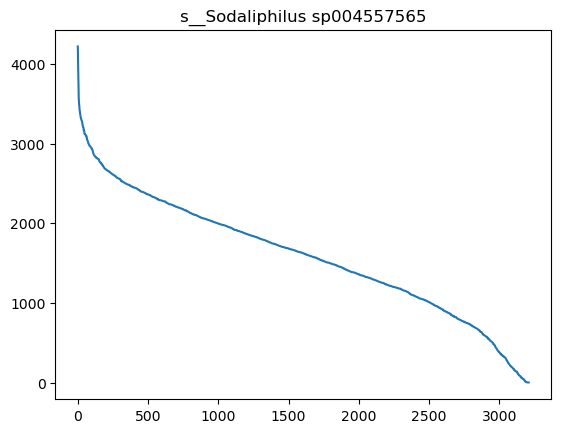

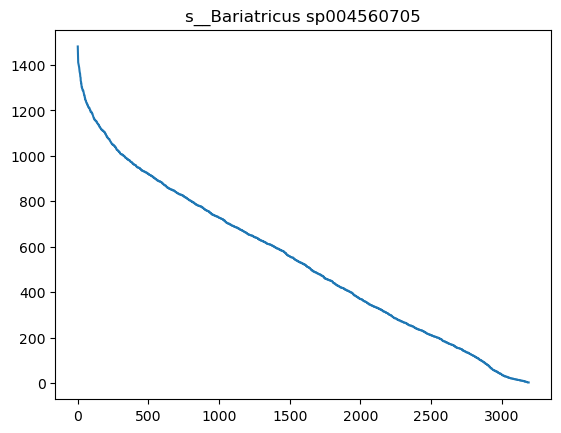

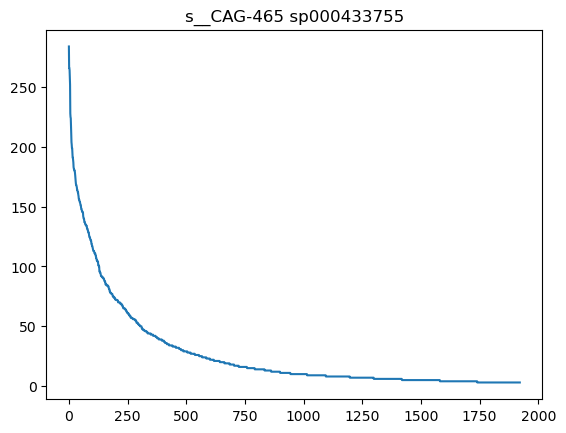

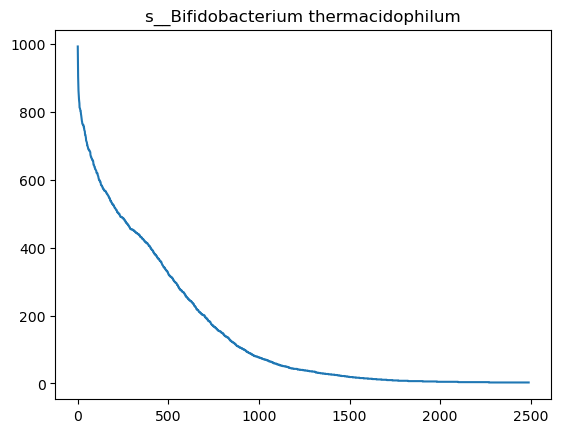

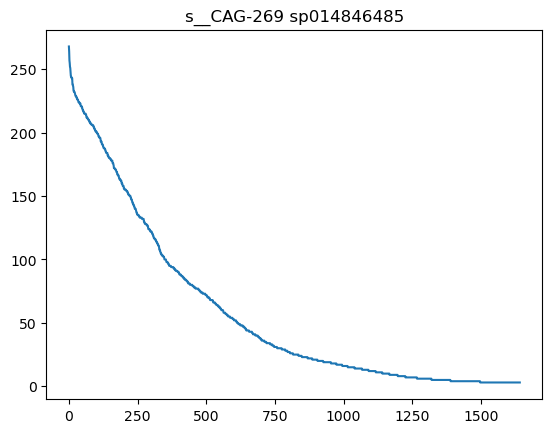

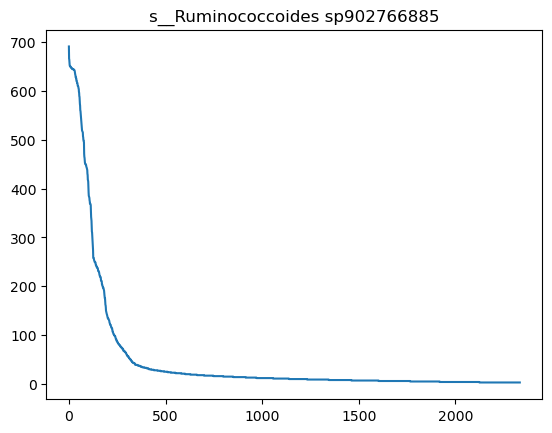

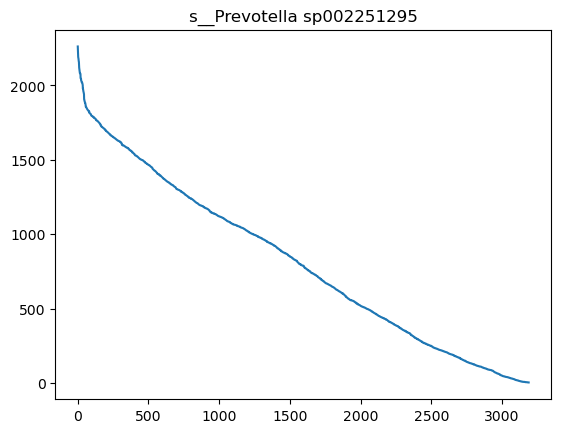

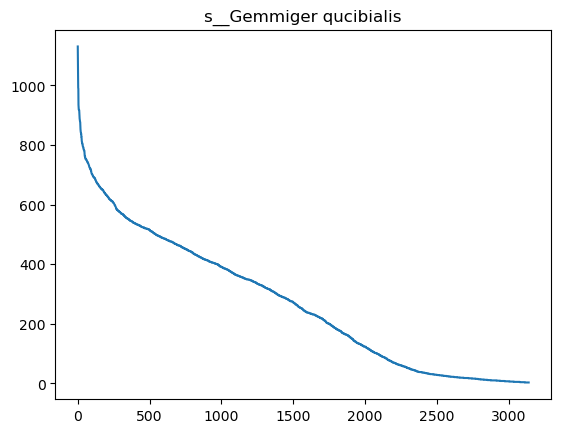

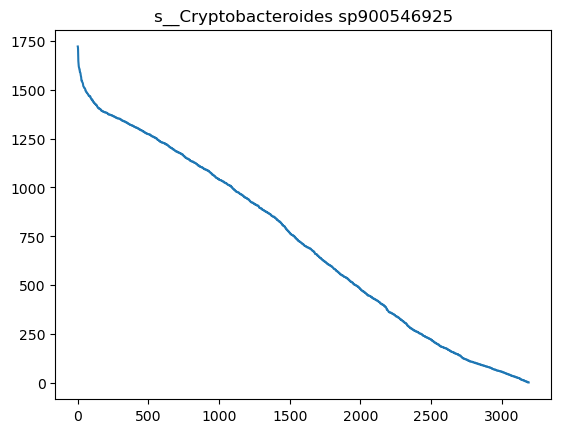

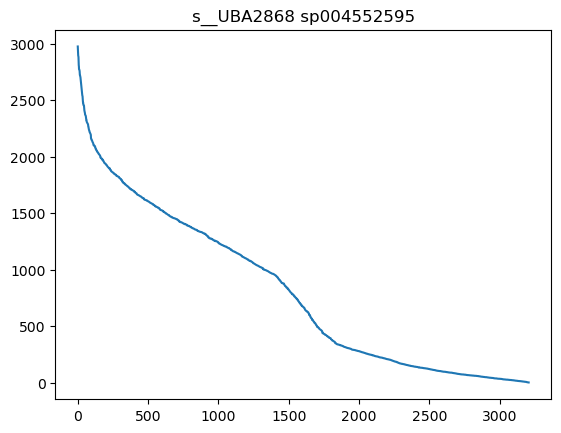

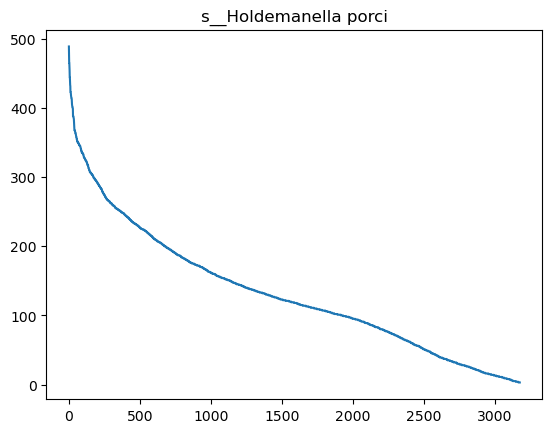

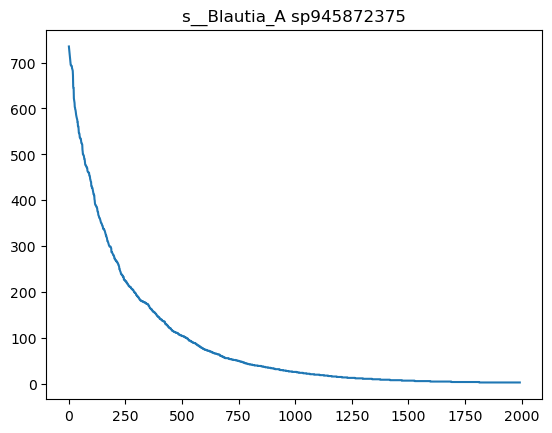

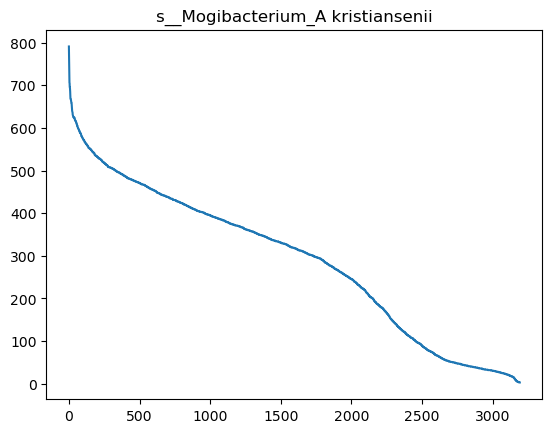

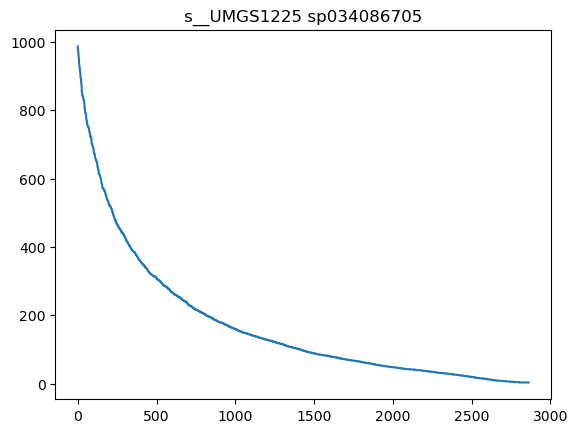

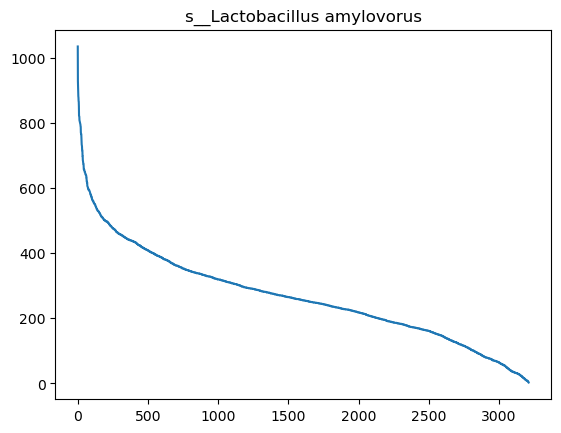

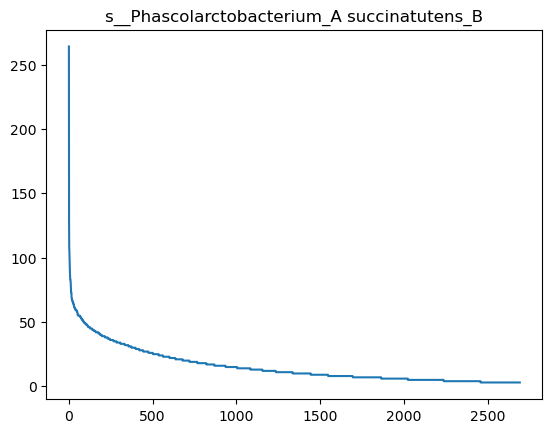

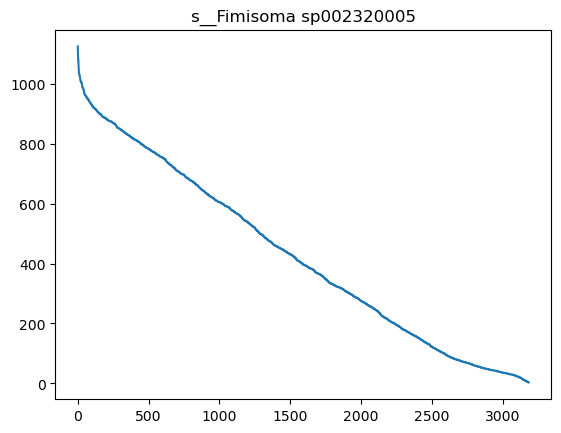

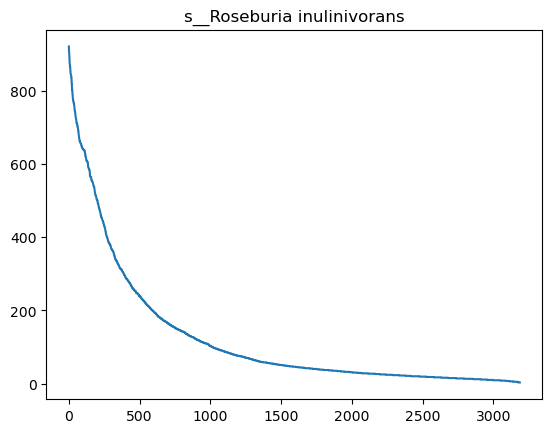

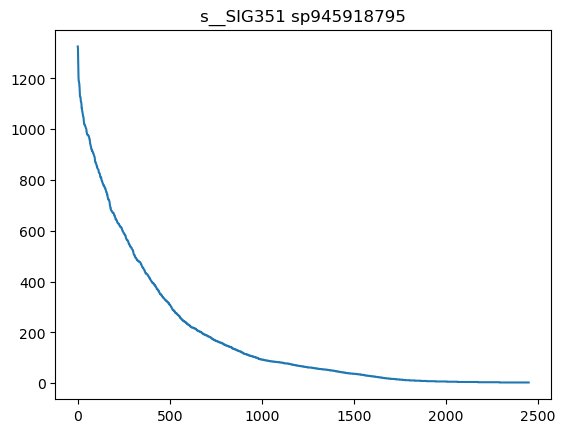

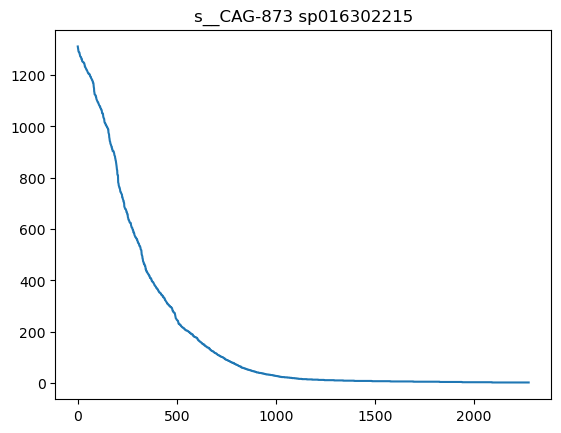

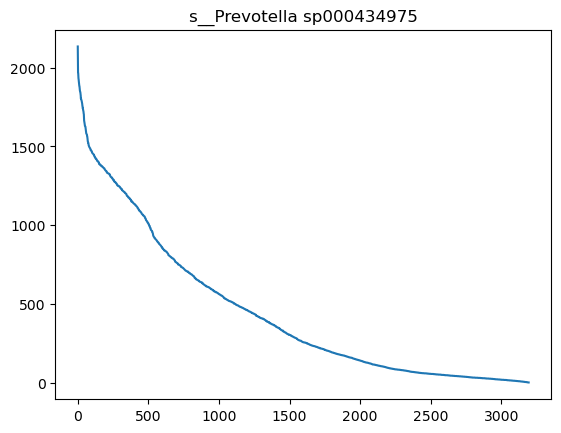

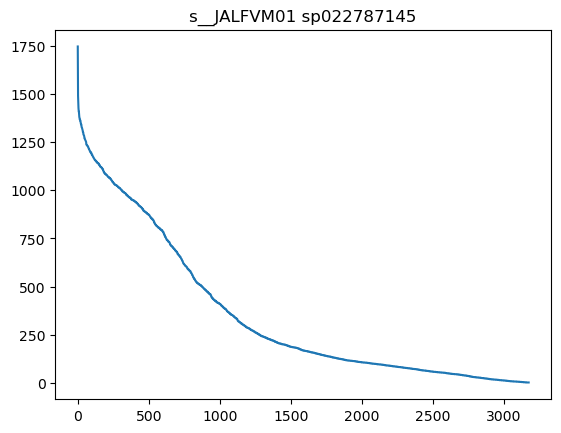

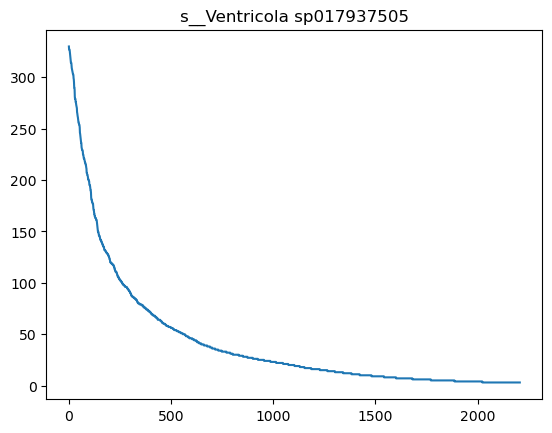

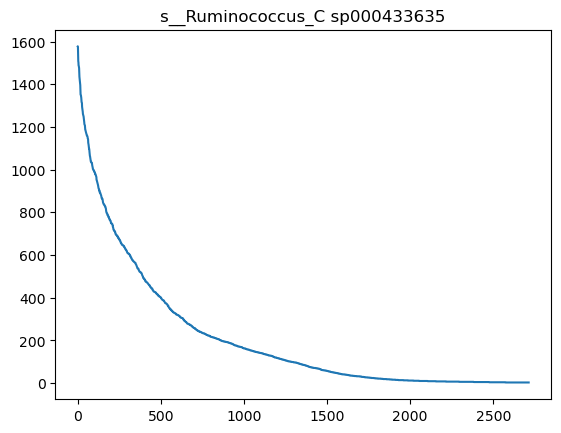

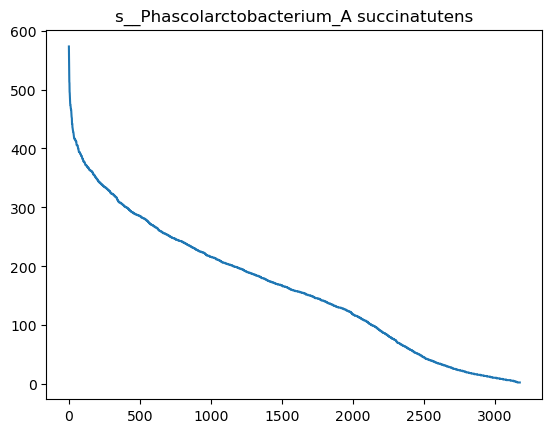

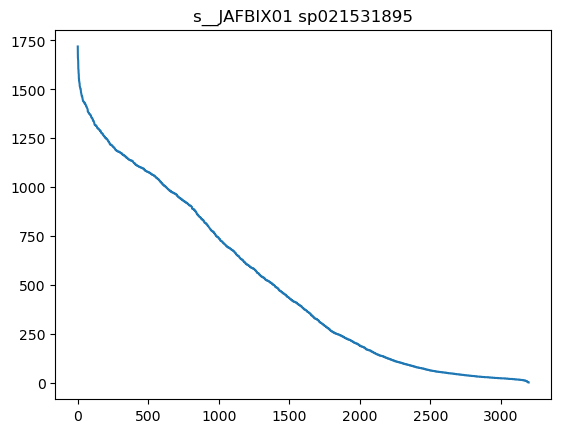

In [94]:
for species in df3['species'].unique():
    foo = (df3.filter(pl.col('species') == species)
           .sort(by='intersect_hashes', descending=True)
           .with_row_index(name='index'))
    plt.plot(foo['index'], foo['intersect_hashes'], label=species)
    #plt.ylim(0, 500)
    plt.title(species)
    plt.show()


In [98]:
combo_pdf = pdf3.join(pdf4, on='species', how='left')
combo_pdf = combo_pdf.join(pdf5, on='species', how='left')
combo_pdf = combo_pdf.join(pdf6, on='species', how='left')

with pl.Config(tbl_rows=-1, tbl_width_chars=-1, fmt_str_lengths=50):
    print(combo_pdf.sort(by='gtdb+bins', descending=True))

shape: (26, 5)
┌────────────────────────────────────────────┬───────────┬───────────┬───────────┬───────────┐
│ species                                    ┆ gtdb+bins ┆ gtdb-only ┆ ath-gtdb  ┆ gtdb-ath  │
│ ---                                        ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str                                        ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════════════════════════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ s__Sodaliphilus sp004557565                ┆ 98.973881 ┆ 98.880597 ┆ 96.548507 ┆ 95.802239 │
│ s__Lactobacillus amylovorus                ┆ 98.476368 ┆ 94.558458 ┆ 95.242537 ┆ 62.064677 │
│ s__Cryptobacteroides sp900546925           ┆ 97.512438 ┆ 96.424129 ┆ 80.410448 ┆ 83.177861 │
│ s__Fimisoma sp002320005                    ┆ 97.077114 ┆ 96.113184 ┆ 49.160448 ┆ 27.114428 │
│ s__Mogibacterium_A kristiansenii           ┆ 97.014925 ┆ 88.774876 ┆ 86.473881 ┆ 22.014925 │
│ s__UBA2868 sp004552595           

In [96]:
foo = combo_pdf.filter(pl.col("gtdb+bins") >= 80)
with pl.Config(tbl_rows=-1, tbl_width_chars=-1, fmt_str_lengths=50):
    print(foo.sort(by='gtdb-ath', descending=False))

shape: (14, 5)
┌──────────────────────────────────────────┬───────────┬───────────┬───────────┬───────────┐
│ species                                  ┆ gtdb+bins ┆ gtdb-only ┆ ath-gtdb  ┆ gtdb-ath  │
│ ---                                      ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str                                      ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞══════════════════════════════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ s__JALFVM01 sp022787145                  ┆ 90.578358 ┆ 63.930348 ┆ 89.334577 ┆ 2.674129  │
│ s__JAFBIX01 sp021531895                  ┆ 96.299751 ┆ 83.333333 ┆ 85.136816 ┆ 18.812189 │
│ s__Holdemanella porci                    ┆ 90.080846 ┆ 79.94403  ┆ 79.850746 ┆ 19.496269 │
│ s__Mogibacterium_A kristiansenii         ┆ 97.014925 ┆ 88.774876 ┆ 86.473881 ┆ 22.014925 │
│ s__Fimisoma sp002320005                  ┆ 97.077114 ┆ 96.113184 ┆ 49.160448 ┆ 27.114428 │
│ s__Phascolarctobacterium_A succinatutens ┆ 87.624378 

In [97]:
foo = combo_pdf.filter(pl.col("gtdb+bins") < 80)
with pl.Config(tbl_rows=-1, tbl_width_chars=-1, fmt_str_lengths=50):
    print(foo.sort(by='gtdb-ath', descending=False))

shape: (12, 5)
┌────────────────────────────────────────────┬───────────┬───────────┬───────────┬───────────┐
│ species                                    ┆ gtdb+bins ┆ gtdb-only ┆ ath-gtdb  ┆ gtdb-ath  │
│ ---                                        ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ str                                        ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════════════════════════════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ s__Phascolarctobacterium_A succinatutens_B ┆ 22.38806  ┆ 22.38806  ┆ null      ┆ null      │
│ s__Blautia_A sp945872375                   ┆ 34.452736 ┆ 34.452736 ┆ null      ┆ null      │
│ s__Ventricola sp017937505                  ┆ 34.328358 ┆ 34.328358 ┆ null      ┆ null      │
│ s__SIG351 sp945918795                      ┆ 52.114428 ┆ 50.34204  ┆ 30.845771 ┆ 0.062189  │
│ s__Ruminococcoides sp902766885             ┆ 19.558458 ┆ 13.743781 ┆ 8.955224  ┆ 1.243781  │
│ s__CAG-269 sp014846485           

In [35]:
df.sort(by='intersect_hashes').filter(pl.col("intersect_hashes") < 20)

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""s__Gemmiger qucibialis""","""0e94a1cb1702f356c4ff288eb771c1…","""SRR11183533""",0.000198,1,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000004,0.000198,2.0,2.0,0.0,0.66628,0.553974,0.610127,0.66628,2,909720
"""s__JAFBIX01 sp021531895""","""4a154f745dd8f3195b612933110567…","""SRR11183533""",0.003086,1,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000004,0.003086,2.0,2.0,0.0,0.759364,0.553974,0.656669,0.759364,2,909720
"""s__Bariatricus sp004560705""","""95217d3abe8cbf2c19de0c711dca3a…","""SRR11183533""",0.002558,1,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000004,0.002558,2.0,2.0,0.0,0.752598,0.553974,0.653286,0.752598,2,909720
"""s__Ruminococcus_C sp000433635""","""9d33cb63ad3d82352fb5735713c8dd…","""SRR11183533""",0.0003,1,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000004,0.0003,1.0,1.0,0.0,0.67954,0.553974,0.616757,0.67954,1,909720
"""s__CAG-269 sp014846485""","""bc3da824edaaa9cbc90f093797c355…","""SRR11124793""",0.004587,1,21,1000,"""DNA""","""9dcfa0182a50721f39df6e5d0f220e…",0.000003,0.004587,1.0,1.0,0.0,0.773829,0.546599,0.660214,0.773829,1,985806
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Lactobacillus amylovorus""","""b290339adedb3a6d2970ddbb10f71c…","""SRR11124962""",0.008418,19,21,1000,"""DNA""","""a952b326976bc6732c31ee442b99d4…",0.000044,0.008418,2.684211,2.0,3.3881,0.796528,0.620122,0.708325,0.796528,51,985529
"""s__Fimisoma sp002320005""","""8e4d8fed12c7c6f207e5d1595bb2af…","""SRR11126296""",0.034173,19,21,1000,"""DNA""","""9e5f4fcb7c6dce784ef5cc4377fc0e…",0.000046,0.034173,1.210526,1.0,0.407682,0.851481,0.621695,0.736588,0.851481,23,1050906
"""s__Bariatricus sp004560705""","""95217d3abe8cbf2c19de0c711dca3a…","""ERR1135408""",0.048593,19,21,1000,"""DNA""","""9ffbe10e0e6b98557adeec053e7710…",0.000011,0.048593,1.052632,1.0,0.223297,0.865877,0.58029,0.723083,0.865877,20,5562310


In [36]:
len(df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD))

24686

In [37]:
for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    print(f"{row['percent']:.1f}% {row['query_name']} ")

0.1% s__SIG351 sp945918795 
1.2% s__Ruminococcoides sp902766885 
2.7% s__JALFVM01 sp022787145 
3.3% s__CAG-269 sp014846485 
7.4% s__CAG-873 sp016302215 
10.9% s__CAG-465 sp000433755 
15.3% s__Bifidobacterium thermacidophilum 
18.8% s__JAFBIX01 sp021531895 
19.5% s__Holdemanella porci 
22.0% s__Mogibacterium_A kristiansenii 
22.9% s__UMGS1225 sp034086705 
27.1% s__Fimisoma sp002320005 
32.8% s__Phascolarctobacterium_A succinatutens 
35.5% s__UBA2868 sp004552595 
36.1% s__Ruminococcus_C sp000433635 
40.0% s__Bariatricus sp004560705 
50.2% s__Prevotella sp002251295 
51.0% s__Roseburia inulinivorans 
60.0% s__Gemmiger qucibialis 
62.1% s__Lactobacillus amylovorus 
69.9% s__Prevotella sp000434975 
83.2% s__Cryptobacteroides sp900546925 
95.8% s__Sodaliphilus sp004557565 


In [38]:
for row in df.filter(pl.col("containment") >= CONTAINMENT_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    print(f"{row['percent']:.1f}% {row['query_name']} ")

16.2% s__Bifidobacterium thermacidophilum 
16.4% s__Roseburia inulinivorans 
16.8% s__Ruminococcoides sp902766885 
25.9% s__CAG-465 sp000433755 
26.1% s__Mogibacterium_A kristiansenii 
27.3% s__Ruminococcus_C sp000433635 
28.2% s__CAG-269 sp014846485 
28.7% s__Gemmiger qucibialis 
30.8% s__CAG-873 sp016302215 
41.6% s__Prevotella sp000434975 
45.0% s__SIG351 sp945918795 
53.4% s__Prevotella sp002251295 
54.5% s__UBA2868 sp004552595 
58.4% s__Lactobacillus amylovorus 
68.7% s__JALFVM01 sp022787145 
69.5% s__Holdemanella porci 
71.4% s__Fimisoma sp002320005 
71.7% s__JAFBIX01 sp021531895 
73.6% s__Cryptobacteroides sp900546925 
73.7% s__Sodaliphilus sp004557565 
76.1% s__Phascolarctobacterium_A succinatutens 
79.2% s__UMGS1225 sp034086705 
86.6% s__Bariatricus sp004560705 


In [39]:
df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""s__Sodaliphilus sp004557565""","""1854e07a4fc71f7b92d67ebb217e54…","""SRR11183533""",0.006601,41,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000164,0.006601,1.585366,1.0,0.764314,0.787358,0.661133,0.724246,0.787358,65,909720
"""s__UBA2868 sp004552595""","""9357c8b5d5771055c412e6de4407c9…","""SRR11183533""",0.007928,7,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000029,0.007928,1.571429,1.0,0.728431,0.794253,0.60776,0.701007,0.794253,11,909720
"""s__Prevotella sp002251295""","""447f2ee95d3a18ae183d26cf7cdaeb…","""SRR11183533""",0.001174,2,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000008,0.001174,5.0,5.0,2.0,0.725196,0.572564,0.64888,0.725196,10,909720
"""s__Gemmiger qucibialis""","""0e94a1cb1702f356c4ff288eb771c1…","""SRR11183533""",0.000198,1,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000004,0.000198,2.0,2.0,0.0,0.66628,0.553974,0.610127,0.66628,2,909720
"""s__Roseburia inulinivorans""","""9776ed5d1ac1ebde4d609c497abe35…","""SRR11183533""",0.001333,8,21,1000,"""DNA""","""d6bb0d581e70eba76d6cf69f4c6bd9…",0.000032,0.001333,2.375,2.0,1.408678,0.729601,0.611637,0.670619,0.729601,19,909720
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Prevotella sp000434975""","""0521860c4039bce6d33aa8a971f8ed…","""SRR17241550""",0.019376,95,21,1000,"""DNA""","""0b3c5e264b5e90c1b8669f89c9e15d…",0.000035,0.019376,6.863158,3.0,14.095621,0.828783,0.61376,0.721272,0.828783,652,17247094
"""s__Bifidobacterium thermacidop…","""ae482a3654f061f8f01a3e5771805c…","""SRR17241550""",0.00108,2,21,1000,"""DNA""","""0b3c5e264b5e90c1b8669f89c9e15d…",7.4299e-7,0.00108,1.0,1.0,0.0,0.722325,0.510689,0.616507,0.722325,2,17247094
"""s__Holdemanella porci""","""d6691c0c036f5330b4f444dec14a34…","""SRR17241550""",0.086777,42,21,1000,"""DNA""","""0b3c5e264b5e90c1b8669f89c9e15d…",0.000016,0.086777,4.0,2.0,3.829708,0.890118,0.590363,0.740241,0.890118,168,17247094


In [40]:
SUB_SPECIES2=(
             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',
#             's__Prevotella sp000434975',
#             's__Holdemanella porci',
)

for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    if row["query_name"] in SUB_SPECIES2:
        print(f"{row['percent']:.1f}% {row['query_name']} ")

22.0% s__Mogibacterium_A kristiansenii 
32.8% s__Phascolarctobacterium_A succinatutens 
50.2% s__Prevotella sp002251295 
83.2% s__Cryptobacteroides sp900546925 


In [41]:
for row in df.filter(pl.col("intersect_hashes") >= HASH_THRESHOLD)['query_name'].value_counts().with_columns(
    (pl.col("count") / 3216 * 100).alias("percent")
).sort(by='percent').iter_rows(named=True):
    print(f"{row['percent']:.1f}% {row['query_name']} ")

0.1% s__SIG351 sp945918795 
1.2% s__Ruminococcoides sp902766885 
2.7% s__JALFVM01 sp022787145 
3.3% s__CAG-269 sp014846485 
7.4% s__CAG-873 sp016302215 
10.9% s__CAG-465 sp000433755 
15.3% s__Bifidobacterium thermacidophilum 
18.8% s__JAFBIX01 sp021531895 
19.5% s__Holdemanella porci 
22.0% s__Mogibacterium_A kristiansenii 
22.9% s__UMGS1225 sp034086705 
27.1% s__Fimisoma sp002320005 
32.8% s__Phascolarctobacterium_A succinatutens 
35.5% s__UBA2868 sp004552595 
36.1% s__Ruminococcus_C sp000433635 
40.0% s__Bariatricus sp004560705 
50.2% s__Prevotella sp002251295 
51.0% s__Roseburia inulinivorans 
60.0% s__Gemmiger qucibialis 
62.1% s__Lactobacillus amylovorus 
69.9% s__Prevotella sp000434975 
83.2% s__Cryptobacteroides sp900546925 
95.8% s__Sodaliphilus sp004557565 
